Libraries loaded successfully! ✅

Loading AI Image Captioning Model...
Please wait...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Model loaded successfully! ✅
Device: cpu

📸 Upload an image


Saving kukur.jpg to kukur.jpg


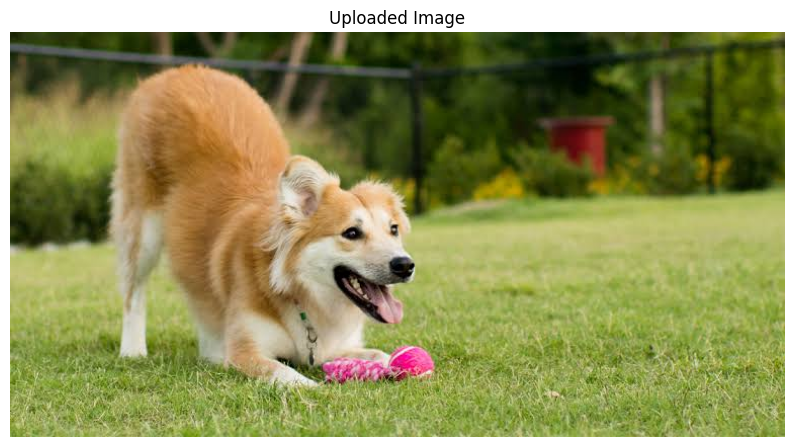


🤖 AI is analyzing the image...

             🖼️ IMAGE CAPTIONING RESULT

Generated Caption:
👉 a dog playing with a ball in the grass

✅ Image caption generated successfully!


In [2]:
# ============================================================
# CODSOFT AI INTERNSHIP - TASK 3
# IMAGE CAPTIONING USING BLIP
# GOOGLE COLAB PROJECT
# ============================================================

# STEP 1: Install required libraries
!pip -q install transformers torch torchvision pillow

# STEP 2: Import libraries
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from google.colab import files
import matplotlib.pyplot as plt

print("Libraries loaded successfully! ✅")


# STEP 3: Load pretrained BLIP model
print("\nLoading AI Image Captioning Model...")
print("Please wait...")

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Model loaded successfully! ✅")
print("Device:", device)


# STEP 4: Upload an image
print("\n📸 Upload an image")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Open image
image = Image.open(image_path).convert("RGB")


# STEP 5: Display uploaded image
plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()


# STEP 6: Generate image caption
print("\n🤖 AI is analyzing the image...")

inputs = processor(
    images=image,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=50,
        num_beams=5
    )

caption = processor.decode(
    output[0],
    skip_special_tokens=True
)


# STEP 7: Display result
print("\n" + "=" * 60)
print("             🖼️ IMAGE CAPTIONING RESULT")
print("=" * 60)

print("\nGenerated Caption:")
print("👉", caption)

print("\n" + "=" * 60)
print("✅ Image caption generated successfully!")
